## 17/10: ¿llueve más con gobierno peronista?

Lluvia del 17 de octubre en Buenos Aires (SMN/OCBA, 1945-2025) contra si ese día hubo gobierno peronista.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

OCBA_URL = "https://raw.githubusercontent.com/ezequiel1593/seguimiento_temperaturas_argentina/refs/heads/main/OCBA/OCBA.csv"
GOBIERNOS_URL = "https://raw.githubusercontent.com/vegafabianr/diecisiete_octubre/refs/heads/main/anios_peronistas.csv"

# Datos diarios del SMN (estación Buenos Aires), 1906-presente
ocba = pd.read_csv(OCBA_URL, sep=";", na_values="NA", parse_dates=["Fecha"])
media_lluvia_bsas = ocba.loc[ocba["Prec"] > 0, "Prec"].mean()  # promedio de un día con lluvia en Bs As

# Nos quedamos solo con los 17 de octubre
df = ocba[(ocba["Fecha"].dt.month == 10) & (ocba["Fecha"].dt.day == 17) & ocba["Prec"].notna()].copy()
df = df.rename(columns={"Fecha": "fecha", "Prec": "precipitacion_mm"})
df["anio"] = df["fecha"].dt.year
df = df[["anio", "fecha", "precipitacion_mm"]]

# Sumamos peronista SI/NO y etapa de gobierno para cada año
gobiernos = pd.read_csv(GOBIERNOS_URL, encoding="utf-8")[["año", "peronista", "etapa"]]
df = df.merge(gobiernos, left_on="anio", right_on="año").drop(columns="año")

df.head(12)

,anio,fecha,precipitacion_mm,peronista,etapa
0,1945,1945-10-17,0.0,SI,Farrell / Perón
1,1946,1946-10-17,0.0,SI,Farrell / Perón
2,1947,1947-10-17,0.0,SI,Farrell / Perón
3,1948,1948-10-17,0.0,SI,Farrell / Perón
4,1949,1949-10-17,0.0,SI,Farrell / Perón
5,1950,1950-10-17,18.8,SI,Farrell / Perón
6,1951,1951-10-17,2.0,SI,Farrell / Perón
7,1952,1952-10-17,2.9,SI,Farrell / Perón
8,1953,1953-10-17,0.1,SI,Farrell / Perón
9,1954,1954-10-17,0.0,SI,Farrell / Perón


In [3]:
# Días con lluvia sobre días totales y mm promedio, peronismo vs no peronismo
df.groupby("peronista")["precipitacion_mm"].agg(
    dias_totales="count",
    dias_con_lluvia=lambda s: (s > 0).sum(),
    promedio_mm="mean",
).assign(prop_lluvia=lambda d: d["dias_con_lluvia"] / d["dias_totales"])

,dias_totales,dias_con_lluvia,promedio_mm,prop_lluvia
peronista,,,,
NO,39,10,2.889744,0.256410
SI,42,11,1.285714,0.261905


## Gráfico 1: 1945-1957

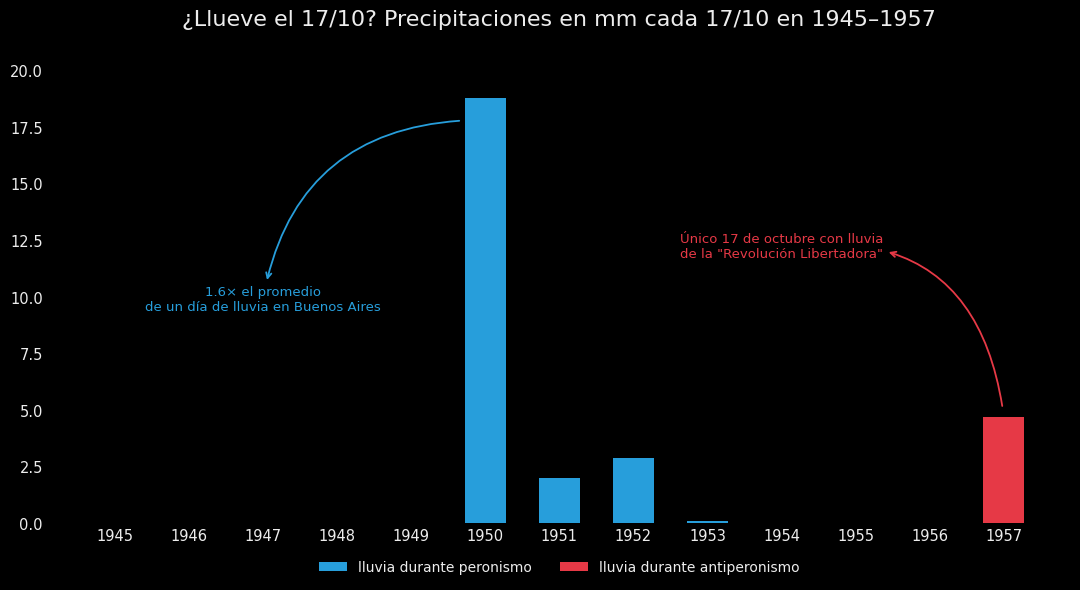

In [11]:
COLOR_SI, COLOR_NO, BG, INK = "#279EDB", "#E63946", "#000000", "#EDEDED"

df1 = df[(df["anio"] >= 1945) & (df["anio"] <= 1957)]
colores = df1["peronista"].map({"SI": COLOR_SI, "NO": COLOR_NO})

fig, ax = plt.subplots(figsize=(11, 6.2))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.bar(df1["anio"], df1["precipitacion_mm"], color=colores, width=0.55)

ax.set_title("¿Llueve el 17/10? Precipitaciones en mm cada 17/10 en 1945–1957", color=INK, fontsize=16)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.spines["left"].set_color(INK)
ax.tick_params(axis="both", length=0, colors=INK, labelsize=10.5)
ax.set_xticks(df1["anio"])
ax.legend(
    handles=[Patch(facecolor=COLOR_SI, label="lluvia durante peronismo"), Patch(facecolor=COLOR_NO, label="lluvia durante antiperonismo")],
    frameon=False, labelcolor=INK, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2,
)

y1950 = df1.loc[df1["anio"] == 1950, "precipitacion_mm"].values[0]
ratio = y1950 / media_lluvia_bsas
ax.annotate(
    f"{ratio:.1f}× el promedio\nde un día de lluvia en Buenos Aires",
    xy=(1950-0.2, y1950-1), xytext=(1947, y1950 * 0.5), color=COLOR_SI, fontsize=9.5, ha="center",
    arrowprops=dict(arrowstyle="<-", color=COLOR_SI, lw=1.3, connectionstyle="arc3,rad=-0.4", shrinkB=8),
)
y1957 = df1.loc[df1["anio"] == 1957, "precipitacion_mm"].values[0]
ax.annotate(
    "Único 17 de octubre con lluvia\nde la \"Revolución Libertadora\"",
    xy=(1957, y1957), xytext=(1954, y1957 * 2.5), color=COLOR_NO, fontsize=9.5, ha="center",
    arrowprops=dict(arrowstyle="<-", color=COLOR_NO, lw=1.3, connectionstyle="arc3,rad=-0.5", shrinkB=8),
)

ax.set_ylim(0, max(df1["precipitacion_mm"]) * 1.15)
plt.subplots_adjust(top=0.87, bottom=0.08, left=0.04, right=0.97)
plt.savefig("grafico_1945_1957_dark.png", dpi=300, facecolor=BG)
plt.show()

## Gráfico 2: % de días de lluvia por gobierno

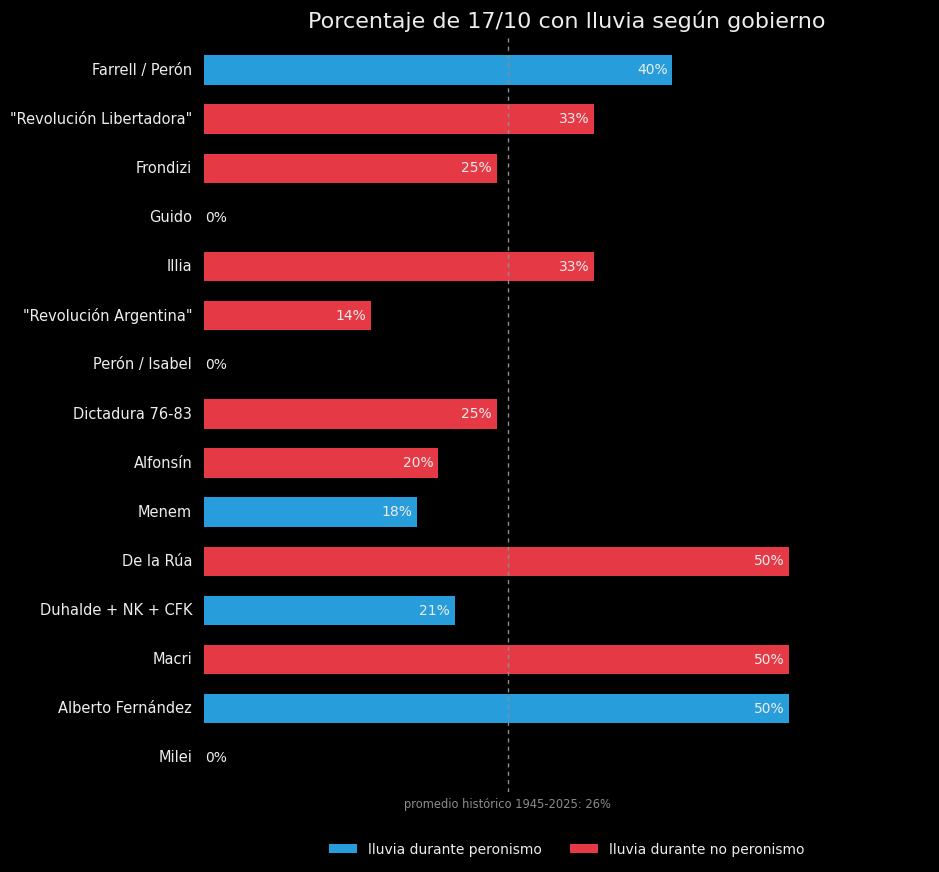

In [12]:
MUTED = "#8C8C8C"

# % de 17 de octubre con lluvia por etapa de gobierno
res = (df.groupby(["etapa", "peronista"], sort=False)
         .agg(y0=("anio", "min"),
              pct=("precipitacion_mm", lambda s: (s > 0).mean() * 100))
         .reset_index().sort_values("y0", ascending=False).reset_index(drop=True))
promedio_general = (df["precipitacion_mm"] > 0).mean() * 100
ypos = np.arange(len(res))
colores = res["peronista"].map({"SI": COLOR_SI, "NO": COLOR_NO})

fig, ax = plt.subplots(figsize=(11, 8.5))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)
ax.barh(ypos, res["pct"], color=colores, height=0.6)
ax.axvline(promedio_general, color=MUTED, lw=1, linestyle=(0, (3, 3)))

ax.set_title("Porcentaje de 17/10 con lluvia según gobierno", color=INK, fontsize=16)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlim(0, 62)
ax.set_ylim(-0.7, len(res) - 0.3)
ax.legend(
    handles=[Patch(facecolor=COLOR_SI, label="lluvia durante peronismo"), Patch(facecolor=COLOR_NO, label="lluvia durante no peronismo")],
    frameon=False, labelcolor=INK, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2,
)

# etiquetas: nombre de la etapa a la izquierda, porcentaje junto a cada barra
for y, row in zip(ypos, res.itertuples()):
    ax.text(-1, y, row.etapa, color=INK, fontsize=10.5, ha="right", va="center")
    if row.pct == 0:
        ax.text(row.pct + 0.1, y, f"{row.pct:.0f}%", color=INK, fontsize=10, ha="left", va="center")
    else:
        ax.text(row.pct - 0.4, y, f"{row.pct:.0f}%", color=INK, fontsize=10, ha="right", va="center")

ax.text(
    promedio_general, -0.95,
    f"promedio histórico {df['anio'].min()}-{df['anio'].max()}: {promedio_general:.0f}%",
    color=MUTED, fontsize=8.3, ha="center", va="center",
)

plt.subplots_adjust(top=0.92, bottom=0.03, left=0.30, right=0.96)
plt.savefig("grafico_por_gobierno.png", dpi=300, facecolor=BG)
plt.show()

## Gráfico 3: distribución de lluvias por día del año

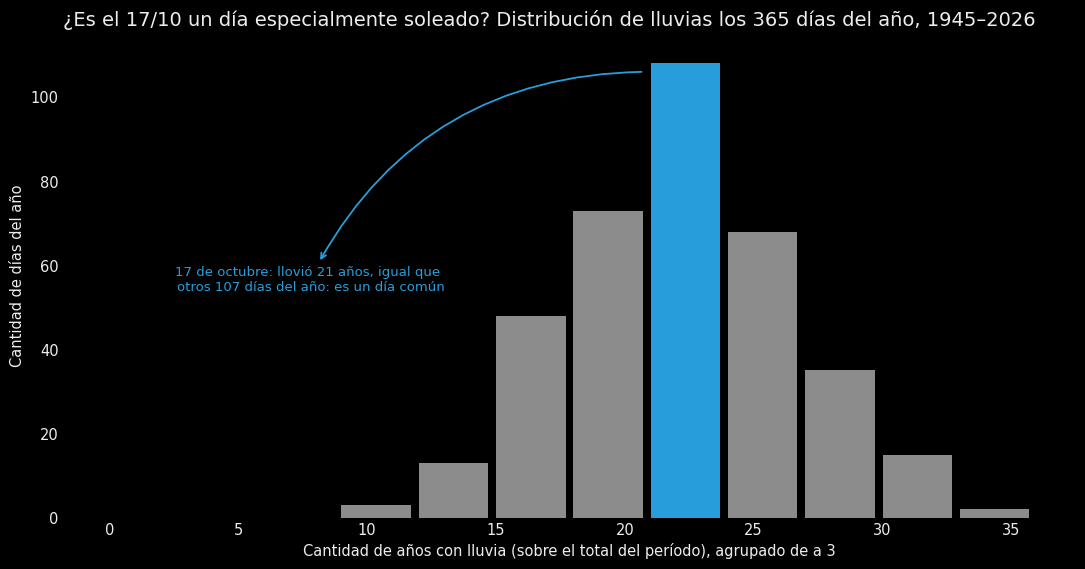

In [18]:
# Serie diaria restringida a los años del período, sin el 29 de febrero
ocba_full = ocba[ocba["Fecha"].dt.year.isin(gobiernos["año"])]
ocba_full = ocba_full[~((ocba_full["Fecha"].dt.month == 2) & (ocba_full["Fecha"].dt.day == 29))]
ocba_full = ocba_full[ocba_full["Prec"].notna()]

# Por cada día del año, en cuántos años llovió
conteo_por_dia = (
    ocba_full.assign(mes=ocba_full["Fecha"].dt.month, dia=ocba_full["Fecha"].dt.day)
    .groupby(["mes", "dia"])["Prec"]
    .apply(lambda s: (s > 0).sum())
)

conteo_17oct = conteo_por_dia.loc[(10, 17)]

# Agrupamos en bins de a 3 años para que la distribución no quede dentada
ancho_bin = 3
bins = range(0, conteo_por_dia.max() + ancho_bin, ancho_bin)
grupos = pd.cut(conteo_por_dia, bins=bins, right=False)  # ej: [20, 25)
frecuencias = grupos.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 6.2))
fig.patch.set_facecolor(BG); ax.set_facecolor(BG)

grupo_17oct = grupos.loc[(10, 17)]
colores_barras = [COLOR_SI if intervalo == grupo_17oct else MUTED for intervalo in frecuencias.index]
xpos = [intervalo.left for intervalo in frecuencias.index]
ax.bar(xpos, frecuencias.values, color=colores_barras, width=ancho_bin * 0.9, align="edge")

ax.set_title(
    f"¿Es el 17/10 un día especialmente soleado? Distribución de lluvias los 365 días del año, {gobiernos['año'].min()}–{gobiernos['año'].max()}",
    color=INK, fontsize=14, loc="left",
)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(axis="both", length=0, colors=INK, labelsize=10.5)
ax.set_xlabel("Cantidad de años con lluvia (sobre el total del período), agrupado de a 3", color=INK, fontsize=10.5)
ax.set_ylabel("Cantidad de días del año", color=INK, fontsize=10.5)
ax.set_ylim(0, 115)

centro_bin = grupo_17oct.left + ancho_bin / 2
otros_dias = frecuencias.loc[grupo_17oct] - 1
ax.annotate(
    f"17 de octubre: llovió {conteo_17oct} años, igual que \notros {otros_dias} días del año: es un día común",
    xy=(centro_bin-1.8, frecuencias.loc[grupo_17oct]-2), xytext=(conteo_17oct - 8, frecuencias.max() * 0.5),
    color=COLOR_SI, fontsize=9.5, ha="right",
    arrowprops=dict(arrowstyle="<-", color=COLOR_SI, lw=1.3, connectionstyle="arc3,rad=-0.3", shrinkB=1),
)

plt.subplots_adjust(top=0.88, bottom=0.1, left=0.05, right=0.97)
plt.savefig("grafico_distribucion_dias.png", dpi=300, facecolor=BG)
plt.show()